# Generate the cross section file for an isochem simulation

In this example, we show how to generate the photolysis cross section file for a specific simulation.

In [1]:
import isochem
import numpy as np
import matplotlib.pyplot as plt
import os

## 1. Selecting files

First, we select the individual files storing the cross sections for each individual molecule.

In [3]:
xsdir = '/home/alday/Documents/Projects/isochem-dist/data/Cross_Sections/'

#LMD setup
############################################################


files = ['CO2/12CO2_LMD.h5',
         'CO2/13CO2_LMD.h5',
         'N2/N2_LMD.h5',
         'H2O/H2O_LMD.h5',
         'NO/NO_LMD.h5',
         'HO2/HO2_LMD.h5',
         'O3/O3_LMD.h5',
         'H2/H2_LMD.h5',
         'H2O2/H2O2_LMD.h5',
         'O2/O2_LMD.h5',
         'NO2/NO2_LMD.h5',
         'N2O/N2O.h5',
         'NO3/NO3.h5']
nfiles = len(files)

combined_filename = 'reference_xs'


In [4]:
#Printing the names of the reactions
ix = 1
temps = []
ntemp = []
nreactions = 0
nreactions_file = np.zeros(nfiles,dtype='int32')
for i in range(len(files)):

    wave,temp,nreactionsx,sID,sISO,npr,pID,pISO,pf = isochem.photolysis.read_header_xs_hdf5(xsdir+files[i])

    for j in range(len(temp)):
        temps.append(temp[j])
    ntemp.append(len(temp))
    
    for j in range(nreactionsx):

        strx = isochem.photolysis.print_photolysis_reaction(sID[j],sISO[j],npr[j],pID[:,j],pISO[:,j],pf[:,j])
        print('Reaction '+str(ix),strx)
        ix += 1

    nreactions += nreactionsx
    nreactions_file[i] = nreactionsx

Reaction 1 CO2 + hv ---> CO + O
Reaction 2 CO2 + hv ---> CO + O(1D)
Reaction 3 (13C)O2 + hv ---> (13C)O + O
Reaction 4 (13C)O2 + hv ---> (13C)O + O(1D)
Reaction 5 N2 + hv ---> N + N(2D)
Reaction 6 N2 + hv ---> N2+ + e-
Reaction 7 H2O + hv ---> OH + H
Reaction 8 NO + hv ---> N + O
Reaction 9 NO + hv ---> NO+ + e-
Reaction 10 HO2 + hv ---> OH + O
Reaction 11 O3 + hv ---> O2 + O
Reaction 12 O3 + hv ---> O2 + O(1D)
Reaction 13 H2 + hv ---> 2*H
Reaction 14 H2O2 + hv ---> 2*OH
Reaction 15 O2 + hv ---> 2*O
Reaction 16 O2 + hv ---> O + O(1D)
Reaction 17 NO2 + hv ---> NO + O
Reaction 18 N2O + hv ---> N2 + O(1D)
Reaction 19 NO3 + hv ---> NO2 + O
Reaction 20 NO3 + hv ---> NO + O2


## 2. Binning the cross sections

Now, we combine all the cross sections into the same file. In this file, we compute all the cross sections to the same wavelength bins.

In [5]:
#Defining the wavelength bins (this is what is used in the Mars PCM)
wl,wu,wc = isochem.photolysis.wlgrid_lmd()
nbin = len(wc)

In [6]:
#Initialising arrays
ngas_inc = len(files)              #Number of gases whose photolysis is included

#Gas and Isotope ID of the photolysed gases
sID_xs = np.zeros(ngas_inc,dtype='int32') ; sISO_xs = np.zeros(ngas_inc,dtype='int32')   

#Reaction information for each of the reactions included
nreactions_br = np.zeros(ngas_inc,dtype='int32')
nreactions_br[:] = nreactions_file
npr_br =  [np.empty((nreactions_file[g]), dtype=np.int32) for g in range(ngas_inc)]
pID_br =  [np.empty((4,nreactions_file[g]), dtype=np.int32) for g in range(ngas_inc)]
pISO_br =  [np.empty((4,nreactions_file[g]), dtype=np.int32) for g in range(ngas_inc)]
pf_br =  [np.empty((4,nreactions_file[g]), dtype=np.int32) for g in range(ngas_inc)]

#Defining the temperatures at which the cross sections should be calculated
temp_bin = [np.empty(ntemp[g], dtype=np.float32) for g in range(ngas_inc)]

#Initialising the binned cross sections and branching ratios
xs_bin = [np.empty((nbin, ntemp[g]), dtype=np.float32) for g in range(ngas_inc)]
branching_ratios_bin = [np.empty((nbin, nreactions_file[g]), dtype=np.float32) for g in range(ngas_inc)]

ix_xs = 0
ix_br = 0
for ifilex in range(ngas_inc):

    #Reading the photolysis file
    wave,temp,xs,nreactionsx,sID,sISO,npr,pID,pISO,pf,branching_ratios = isochem.photolysis.read_xs_hdf5(xsdir+files[ifilex])

    #Preparing the cross sections and branching ratios
    xs_bin[ifilex][:,:], branching_ratios_bin[ifilex] = isochem.photolysis.prepare_xs(temp,wave,xs,nreactions_file[ifilex],branching_ratios,wc,temp)
    temp_bin[ifilex][:] = temp
    
    sID_xs[ix_xs] = sID[0] ; sISO_xs[ix_xs] = sISO[0]
    npr_br[ifilex] = npr[:]
    pID_br[ifilex][:,:] = pID[:,:] ; pISO_br[ifilex][:,:] = pISO[:,:] ; pf_br[ifilex][:,:] = pf[:,:]
    
    ix_br += nreactions_file[ifilex]
    ix_xs += 1


In [7]:
#Printing reactions to make sure they are the same we chose
ix = 1
for i in range(ngas_inc):
    for j in range(nreactions_br[i]):
        strx = isochem.photolysis.print_photolysis_reaction(sID_xs[i],sISO_xs[i],npr_br[i][j],pID_br[i][:,j],pISO_br[i][:,j],pf_br[i][:,j])
        print('Reaction '+str(ix),strx)
        ix += 1

Reaction 1 CO2 + hv ---> CO + O
Reaction 2 CO2 + hv ---> CO + O(1D)
Reaction 3 (13C)O2 + hv ---> (13C)O + O
Reaction 4 (13C)O2 + hv ---> (13C)O + O(1D)
Reaction 5 N2 + hv ---> N + N(2D)
Reaction 6 N2 + hv ---> N2+ + e-
Reaction 7 H2O + hv ---> OH + H
Reaction 8 NO + hv ---> N + O
Reaction 9 NO + hv ---> NO+ + e-
Reaction 10 HO2 + hv ---> OH + O
Reaction 11 O3 + hv ---> O2 + O
Reaction 12 O3 + hv ---> O2 + O(1D)
Reaction 13 H2 + hv ---> 2*H
Reaction 14 H2O2 + hv ---> 2*OH
Reaction 15 O2 + hv ---> 2*O
Reaction 16 O2 + hv ---> O + O(1D)
Reaction 17 NO2 + hv ---> NO + O
Reaction 18 N2O + hv ---> N2 + O(1D)
Reaction 19 NO3 + hv ---> NO2 + O
Reaction 20 NO3 + hv ---> NO + O2


/tmp/ipykernel_680677/3708361676.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


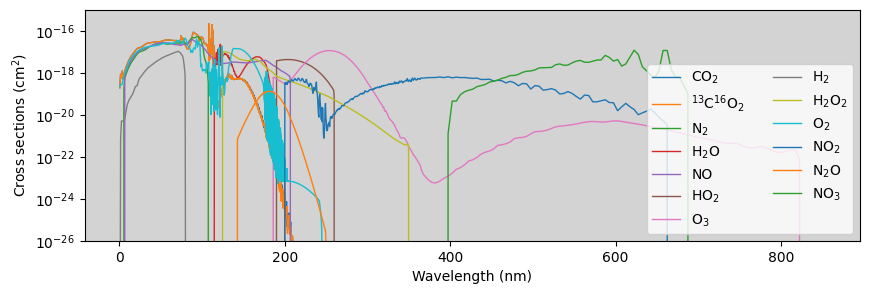

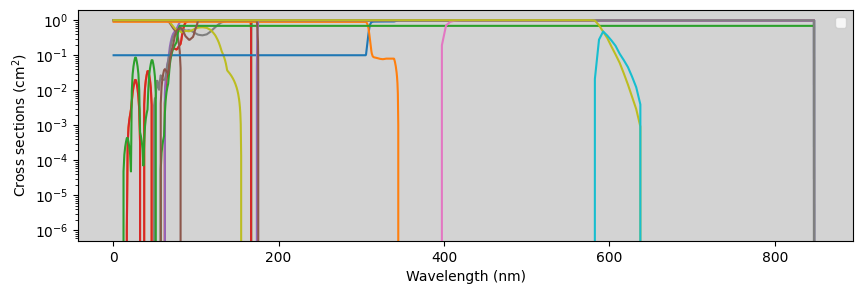

In [8]:
fig,ax1 = plt.subplots(1,1,figsize=(10,3))
for i in range(ngas_inc):
    label = isochem.id_to_label(sID_xs[i],sISO_xs[i])
    ax1.plot(wc,xs_bin[i][:,0],label=str(label),linewidth=1.)
ax1.legend(ncol=2)
ax1.set_ylim(bottom=1.0e-26,top=1.0e-15)
ax1.set_facecolor('lightgray')
ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('Cross sections (cm$^2$)')
ax1.set_yscale('log')

fig,ax1 = plt.subplots(1,1,figsize=(10,3))
for i in range(ngas_inc):
    ax1.plot(wc,branching_ratios_bin[i][:,:])
ax1.legend()
ax1.set_facecolor('lightgray')
ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('Cross sections (cm$^2$)')
ax1.set_yscale('log')

## 4. Writing the combined file

In [9]:
if os.path.exists(combined_filename+'.h5'):
    os.remove(combined_filename+'.h5')

isochem.photolysis.write_xs_combined_hdf5(combined_filename,wl,wc,wu,ngas_inc,sID_xs,sISO_xs,temp_bin,xs_bin,nreactions_br,npr_br,pID_br,pISO_br,pf_br,branching_ratios_bin)
        